In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
BASE_PATH = "../data/raw"

train = pd.read_csv(f"{BASE_PATH}/train.csv")
stores = pd.read_csv(f"{BASE_PATH}/stores.csv")
oil = pd.read_csv(f"{BASE_PATH}/oil.csv")
holidays = pd.read_csv(f"{BASE_PATH}/holidays_events.csv")

train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [8]:
sales = train.groupby("date")["sales"].sum()
sales.index = pd.to_datetime(sales.index)

sales.head()

date
2013-01-01      2511.618999
2013-01-02    496092.417944
2013-01-03    361461.231124
2013-01-04    354459.677093
2013-01-05    477350.121229
Name: sales, dtype: float64

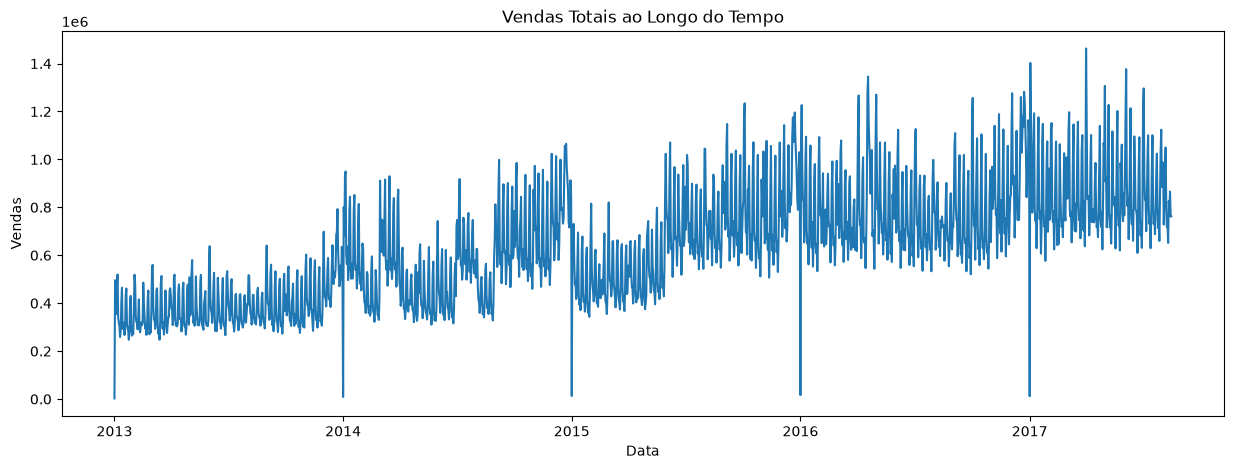

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(sales)
plt.title("Vendas Totais ao Longo do Tempo")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.show()

In [10]:
sales.isnull().sum()

np.int64(0)

In [11]:
sales.index.min(), sales.index.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [12]:
sales.index.to_series().diff().value_counts().head()

date
1 days    1679
2 days       4
Name: count, dtype: int64

In [15]:
sales = sales.ffill()

In [16]:
sales.isnull().sum()

np.int64(0)

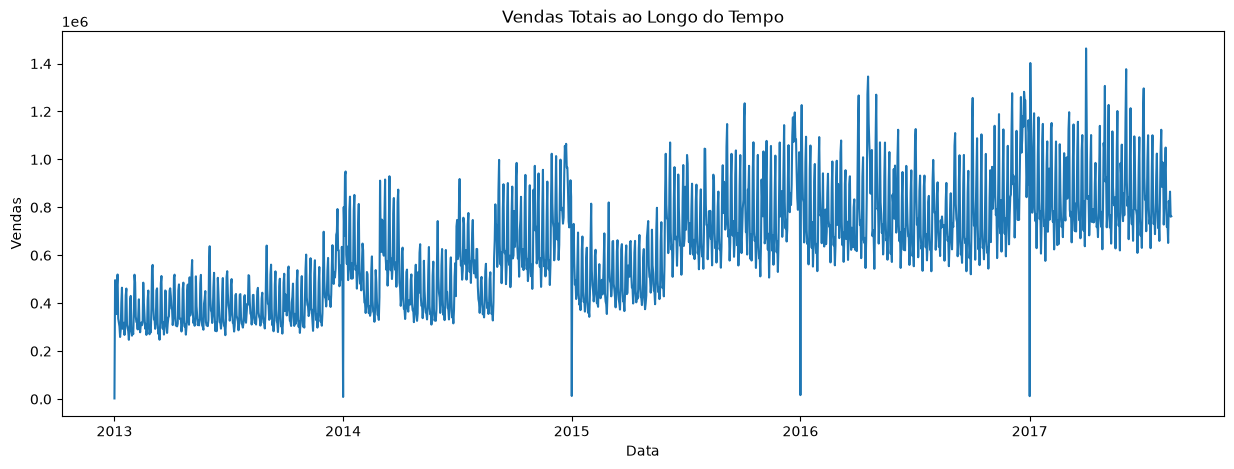

In [17]:
plt.figure(figsize=(15,5))
plt.plot(sales)
plt.title("Vendas Totais ao Longo do Tempo")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.show()

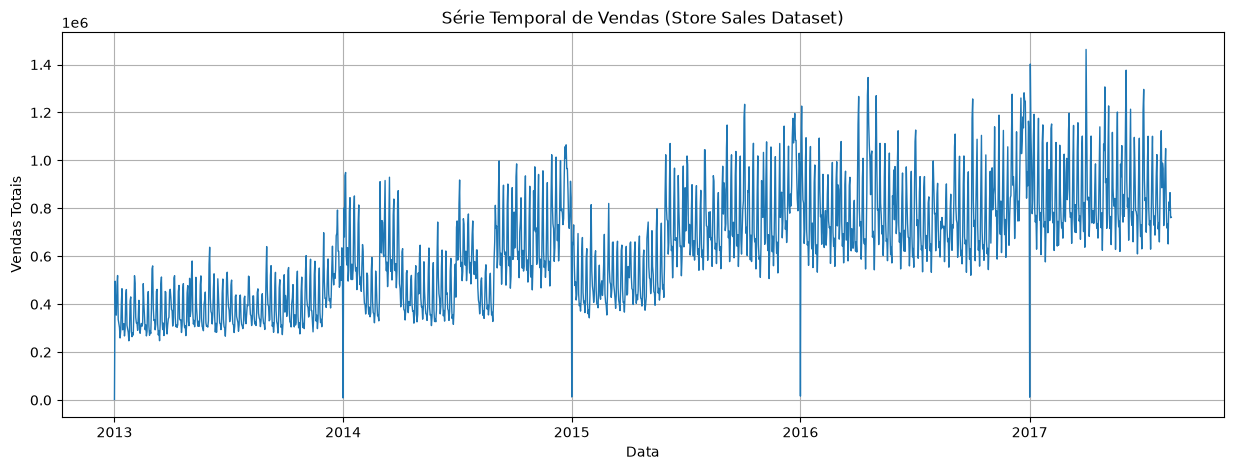

In [18]:
plt.figure(figsize=(15,5))
plt.plot(sales, linewidth=1)
plt.title("Série Temporal de Vendas (Store Sales Dataset)")
plt.xlabel("Data")
plt.ylabel("Vendas Totais")
plt.grid(True)
plt.show()

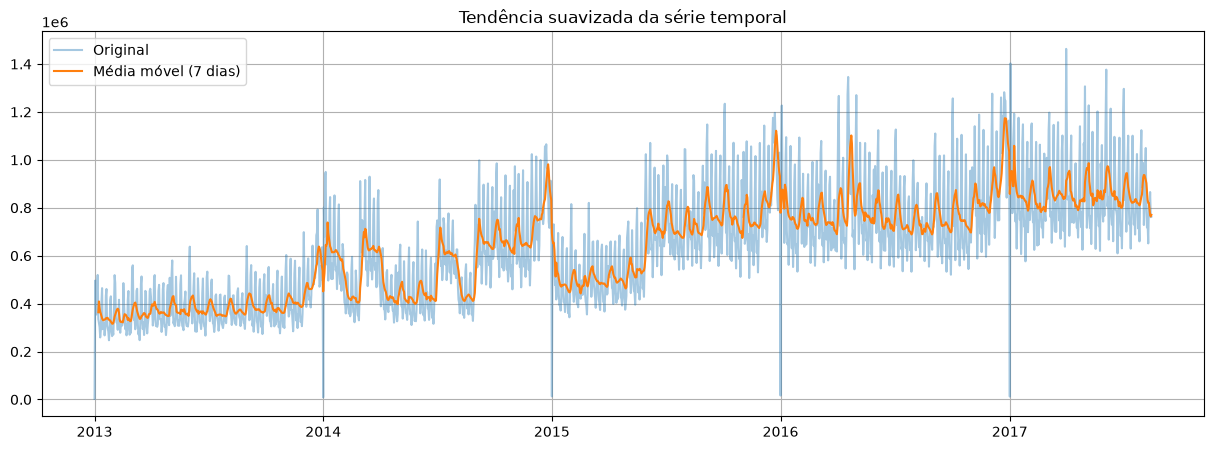

In [19]:
sales_ma7 = sales.rolling(window=7).mean()

plt.figure(figsize=(15,5))
plt.plot(sales, alpha=0.4, label="Original")
plt.plot(sales_ma7, label="Média móvel (7 dias)")
plt.legend()
plt.title("Tendência suavizada da série temporal")
plt.grid(True)
plt.show()

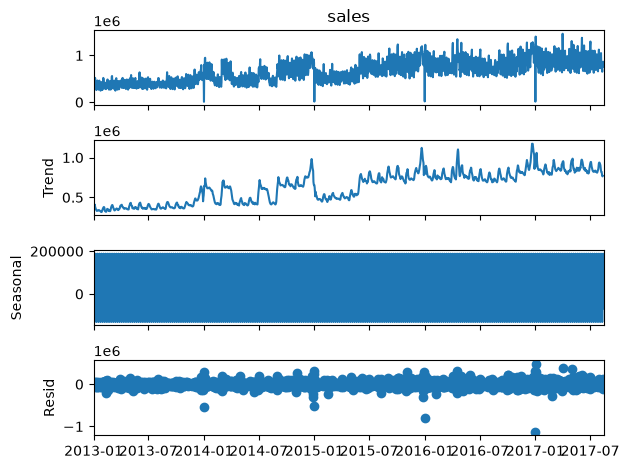

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(sales, model='additive', period=7)

result.plot()
plt.show()

In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

<Figure size 1200x500 with 0 Axes>

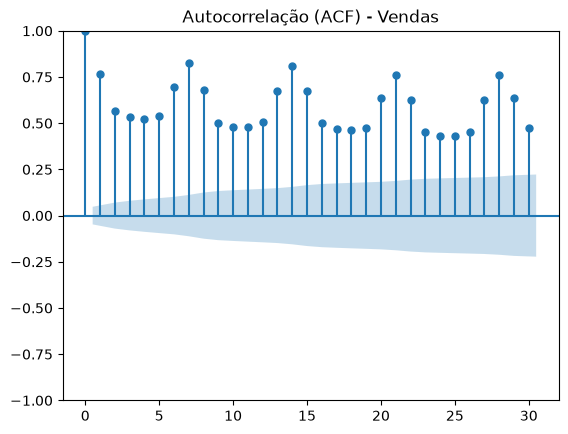

In [25]:
plt.figure(figsize=(12,5))
plot_acf(sales, lags=30)
plt.title("Autocorrelação (ACF) - Vendas")
plt.show()

<Figure size 1200x500 with 0 Axes>

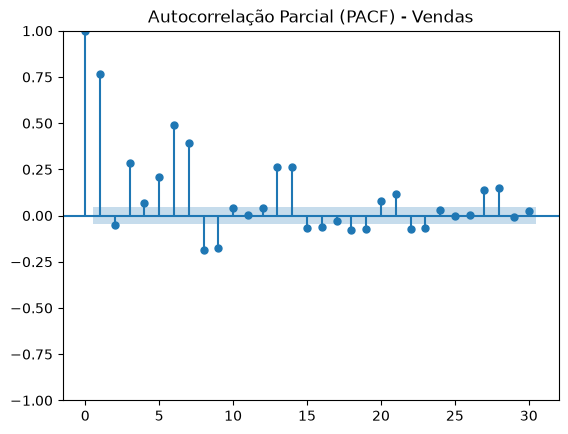

In [26]:
plt.figure(figsize=(12,5))
plot_pacf(sales, lags=30)
plt.title("Autocorrelação Parcial (PACF) - Vendas")
plt.show()

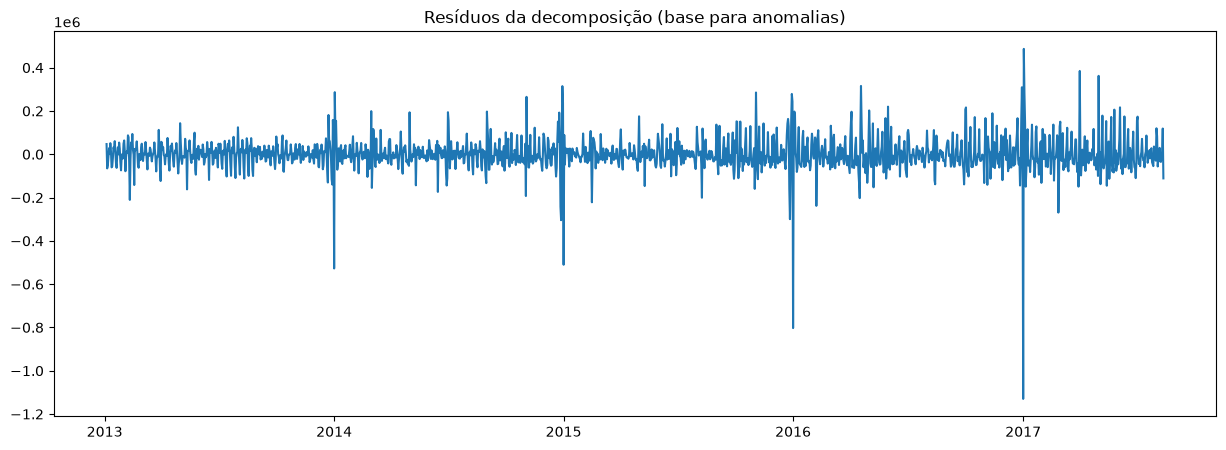

In [27]:
residual = result.resid

plt.figure(figsize=(15,5))
plt.plot(residual)
plt.title("Resíduos da decomposição (base para anomalias)")
plt.show()

In [28]:
residual_mean = residual.mean()
residual_std = residual.std()

upper_limit = residual_mean + 2 * residual_std
lower_limit = residual_mean - 2 * residual_std

In [29]:
anomalies = residual[(residual > upper_limit) | (residual < lower_limit)]

anomalies.head()

date
2013-02-10   -210743.614694
2013-05-12   -162053.621727
2013-12-23    181405.168184
2013-12-30    158388.340788
2014-01-01   -527498.985237
Name: resid, dtype: float64

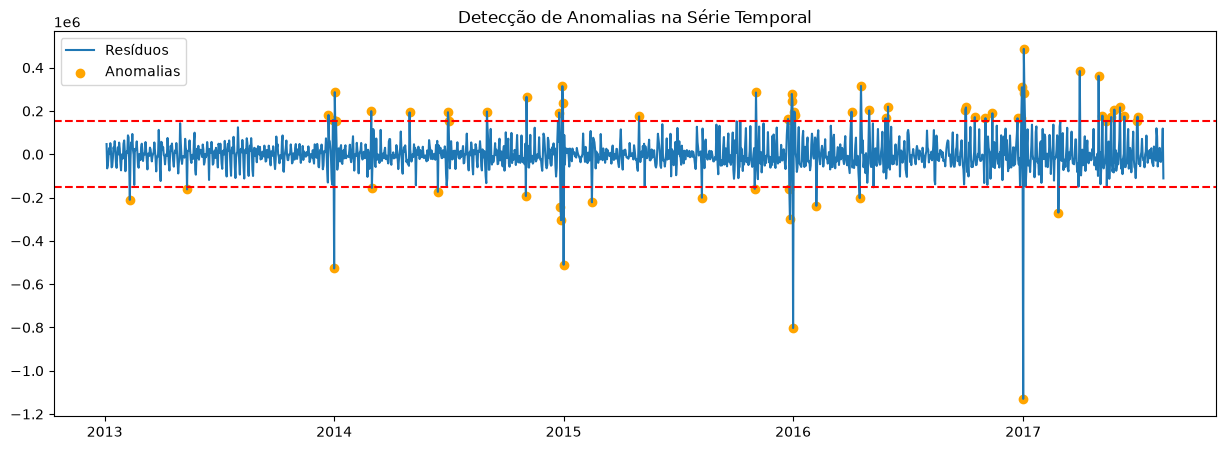

In [30]:
plt.figure(figsize=(15,5))
plt.plot(residual, label="Resíduos")
plt.axhline(upper_limit, color="red", linestyle="--")
plt.axhline(lower_limit, color="red", linestyle="--")
plt.scatter(anomalies.index, anomalies, color="orange", label="Anomalias")
plt.legend()
plt.title("Detecção de Anomalias na Série Temporal")
plt.show()

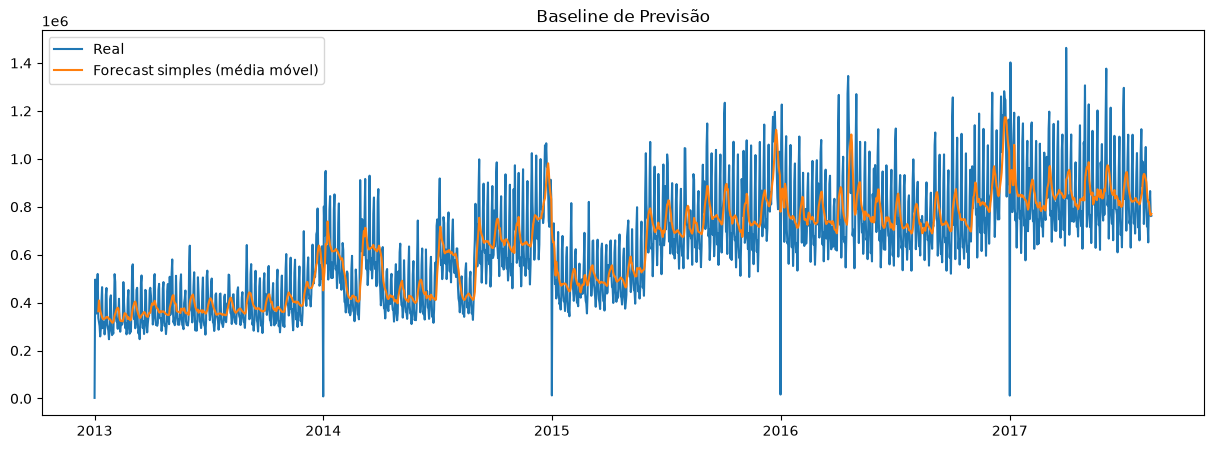

In [31]:
forecast = sales.rolling(window=7).mean()

plt.figure(figsize=(15,5))
plt.plot(sales, label="Real")
plt.plot(forecast, label="Forecast simples (média móvel)")
plt.legend()
plt.title("Baseline de Previsão")
plt.show()

In [32]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [33]:
model = ExponentialSmoothing(
    sales,
    trend="add",
    seasonal="add",
    seasonal_periods=7
)

hw_fit = model.fit()
forecast_hw = hw_fit.fittedvalues

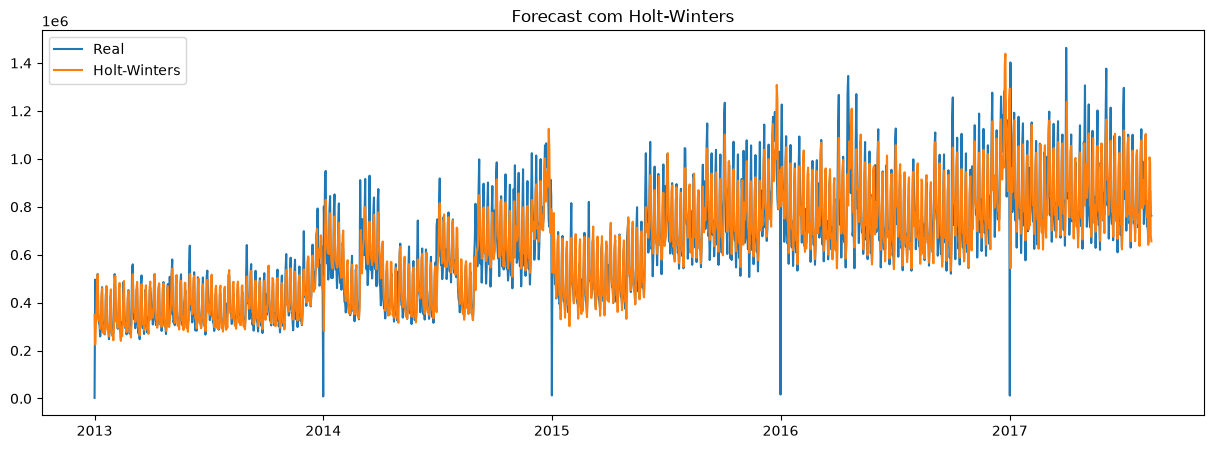

In [34]:
plt.figure(figsize=(15,5))
plt.plot(sales, label="Real")
plt.plot(forecast_hw, label="Holt-Winters")
plt.legend()
plt.title("Forecast com Holt-Winters")
plt.show()

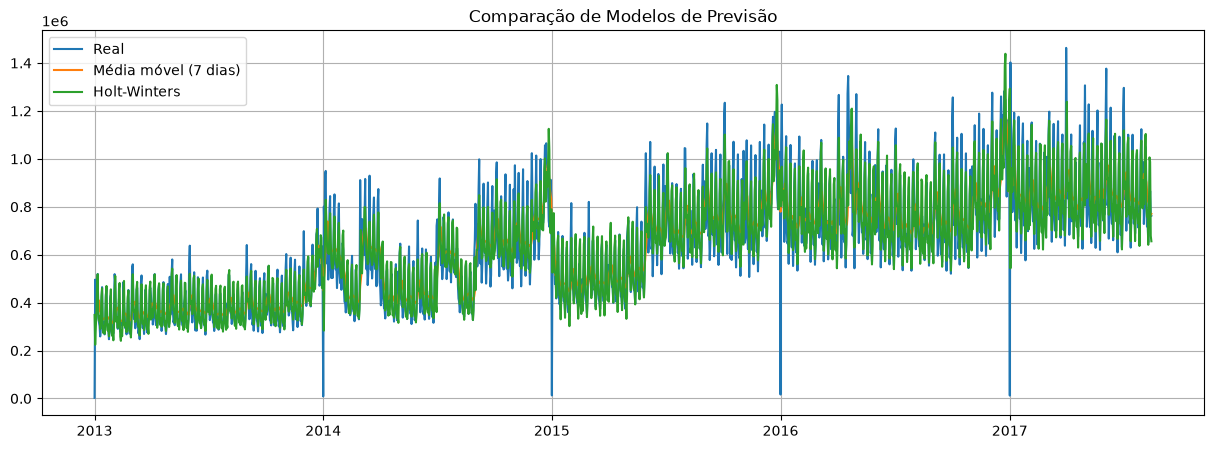

In [35]:
plt.figure(figsize=(15,5))

plt.plot(sales, label="Real")
plt.plot(forecast, label="Média móvel (7 dias)")
plt.plot(forecast_hw, label="Holt-Winters")

plt.legend()
plt.title("Comparação de Modelos de Previsão")
plt.grid(True)
plt.show()

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [39]:
mae_ma = mean_absolute_error(sales[7:], forecast[7:])
rmse_ma = np.sqrt(mean_squared_error(sales[7:], forecast[7:]))

print("MAE Média Móvel:", mae_ma)
print("RMSE Média Móvel:", rmse_ma)

MAE Média Móvel: 108311.32561630436
RMSE Média Móvel: 138000.94815573416


In [40]:
mae_hw = mean_absolute_error(sales, forecast_hw)
rmse_hw = np.sqrt(mean_squared_error(sales, forecast_hw))

print("MAE Holt-Winters:", mae_hw)
print("RMSE Holt-Winters:", rmse_hw)

MAE Holt-Winters: 55616.60197721058
RMSE Holt-Winters: 94051.04562970859


In [42]:
forecast_baseline = sales.rolling(window=7).mean()

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# remover NaN (importante na média móvel)
y_true = sales[forecast_baseline.notna()]
y_pred = forecast_baseline.dropna()

mae_baseline = mean_absolute_error(y_true, y_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_true, y_pred))

print(mae_baseline, rmse_baseline)

108263.47903755175 137961.5884286282


In [44]:
mae_hw = 55616.60
rmse_hw = 94051.04

In [45]:
print("=== COMPARAÇÃO DE MODELOS ===")

print(f"MAE Baseline (Média móvel): {mae_baseline:.2f}")
print(f"MAE Holt-Winters: {mae_hw:.2f}")

print(f"RMSE Baseline (Média móvel): {rmse_baseline:.2f}")
print(f"RMSE Holt-Winters: {rmse_hw:.2f}")

=== COMPARAÇÃO DE MODELOS ===
MAE Baseline (Média móvel): 108263.48
MAE Holt-Winters: 55616.60
RMSE Baseline (Média móvel): 137961.59
RMSE Holt-Winters: 94051.04


## 📌 Conclusão

O modelo Holt-Winters apresentou desempenho superior ao baseline, reduzindo significativamente MAE e RMSE.

Isso demonstra a presença de tendência e sazonalidade na série temporal, reforçando a necessidade de modelos estatísticos mais robustos para previsão de demanda.

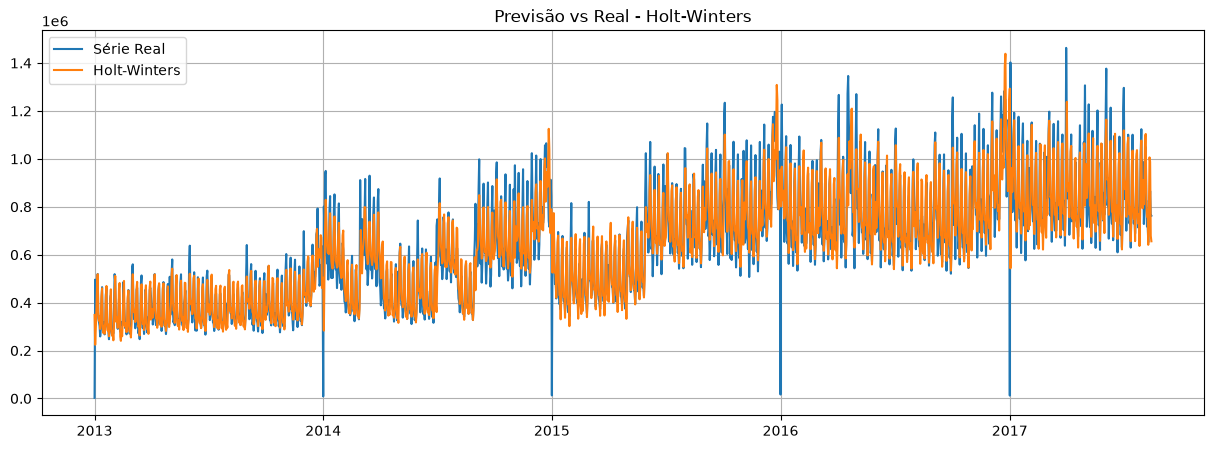

In [47]:
plt.figure(figsize=(15,5))
plt.plot(sales, label="Série Real")
plt.plot(forecast_hw, label="Holt-Winters")
plt.title("Previsão vs Real - Holt-Winters")
plt.legend()
plt.grid(True)
plt.show()

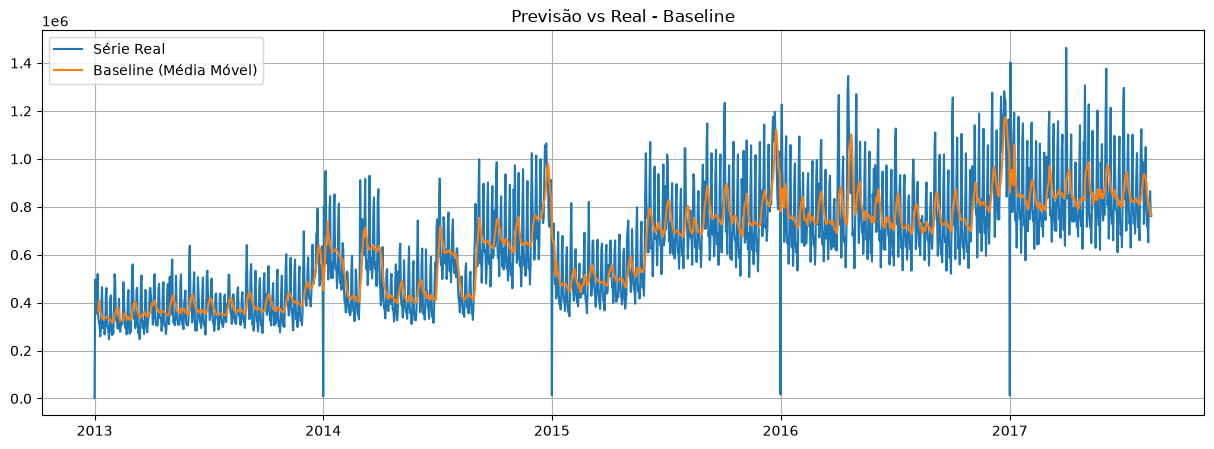

In [48]:
plt.figure(figsize=(15,5))
plt.plot(sales, label="Série Real")
plt.plot(forecast_baseline, label="Baseline (Média Móvel)")
plt.title("Previsão vs Real - Baseline")
plt.legend()
plt.grid(True)
plt.show()

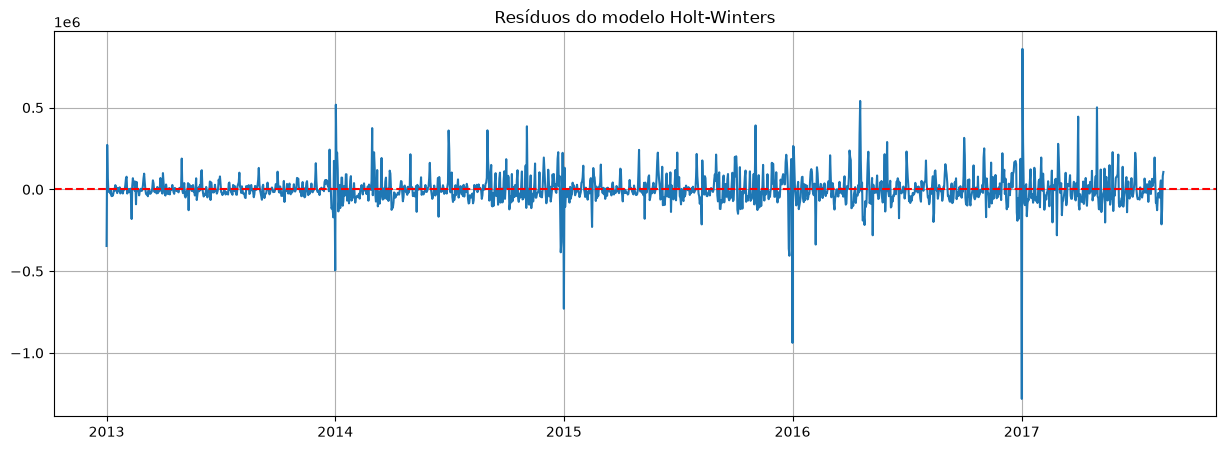

In [49]:
residuals = sales - forecast_hw

plt.figure(figsize=(15,5))
plt.plot(residuals)
plt.title("Resíduos do modelo Holt-Winters")
plt.axhline(0, color="red", linestyle="--")
plt.grid(True)
plt.show()

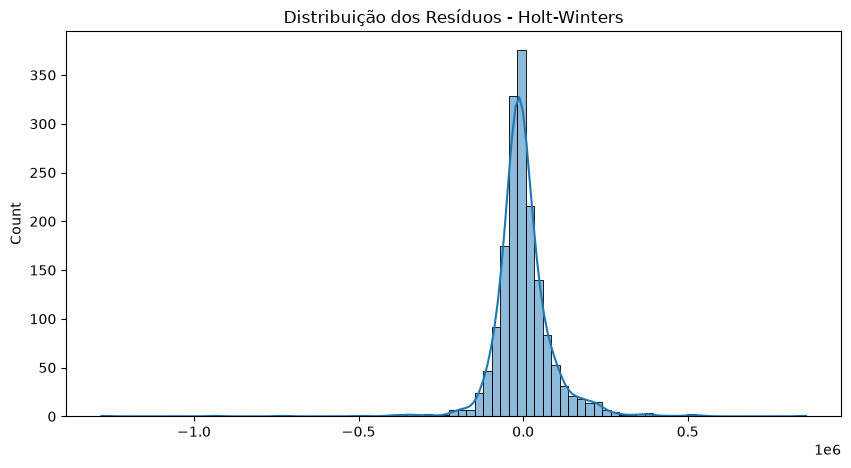

In [50]:
plt.figure(figsize=(10,5))
sns.histplot(residuals, kde=True)
plt.title("Distribuição dos Resíduos - Holt-Winters")
plt.show()

In [51]:
print("Média dos resíduos:", residuals.mean())
print("Desvio padrão dos resíduos:", residuals.std())

Média dos resíduos: -188.6265339385933
Desvio padrão dos resíduos: 94078.72752717338


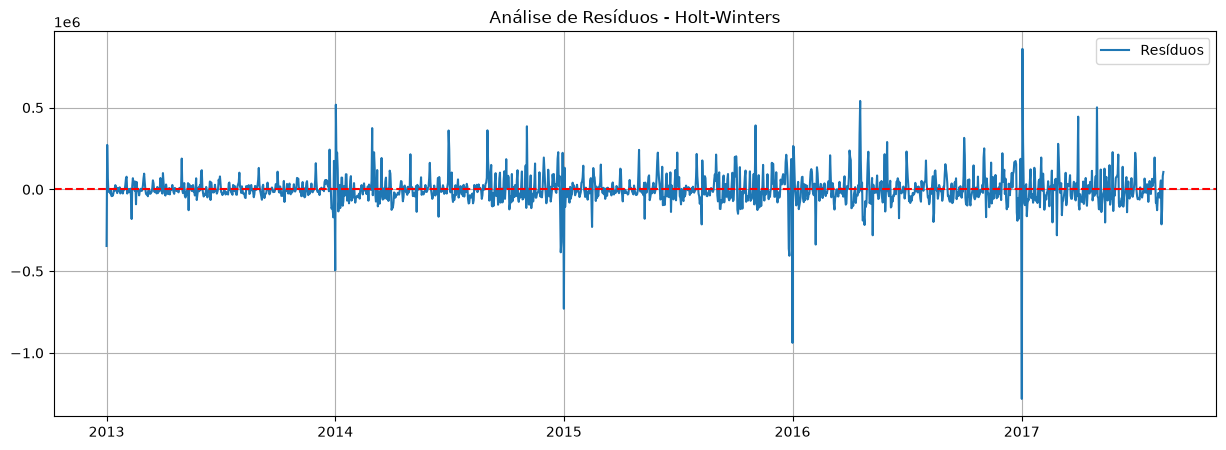

In [52]:
plt.figure(figsize=(15,5))
plt.plot(residuals, label="Resíduos")
plt.axhline(0, color="red", linestyle="--")
plt.title("Análise de Resíduos - Holt-Winters")
plt.legend()
plt.grid(True)
plt.show()

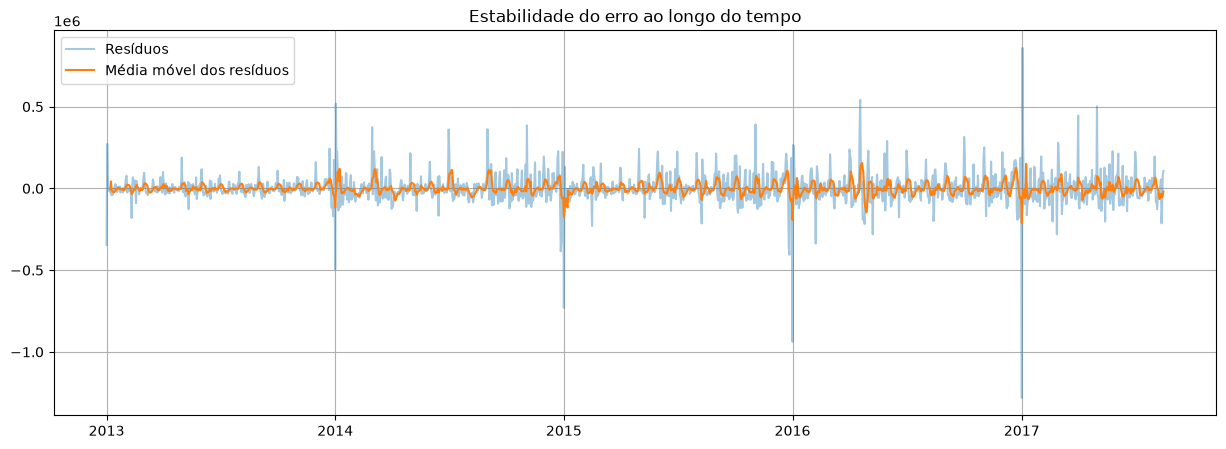

In [53]:
residuals_ma = residuals.rolling(window=7).mean()

plt.figure(figsize=(15,5))
plt.plot(residuals, alpha=0.4, label="Resíduos")
plt.plot(residuals_ma, label="Média móvel dos resíduos")
plt.title("Estabilidade do erro ao longo do tempo")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
print("Resumo do Modelo Holt-Winters")
print("--------------------------------")
print(f"MAE: {mae_hw:.2f}")
print(f"RMSE: {rmse_hw:.2f}")
print(f"Média dos resíduos: {residuals.mean():.2f}")
print(f"Desvio padrão dos resíduos: {residuals.std():.2f}")

Resumo do Modelo Holt-Winters
--------------------------------
MAE: 55616.60
RMSE: 94051.04
Média dos resíduos: -188.63
Desvio padrão dos resíduos: 94078.73


## 📊 Insights de Negócio

A análise da série temporal indica que a demanda apresenta comportamento sazonal e tendência bem definida, o que justifica o desempenho superior de modelos como Holt-Winters em relação ao baseline.

A variabilidade observada sugere que decisões baseadas apenas em médias simples não são suficientes para capturar o comportamento real da demanda.

Portanto, modelos estatísticos estruturados são essenciais para previsões mais confiáveis e apoio à tomada de decisão.

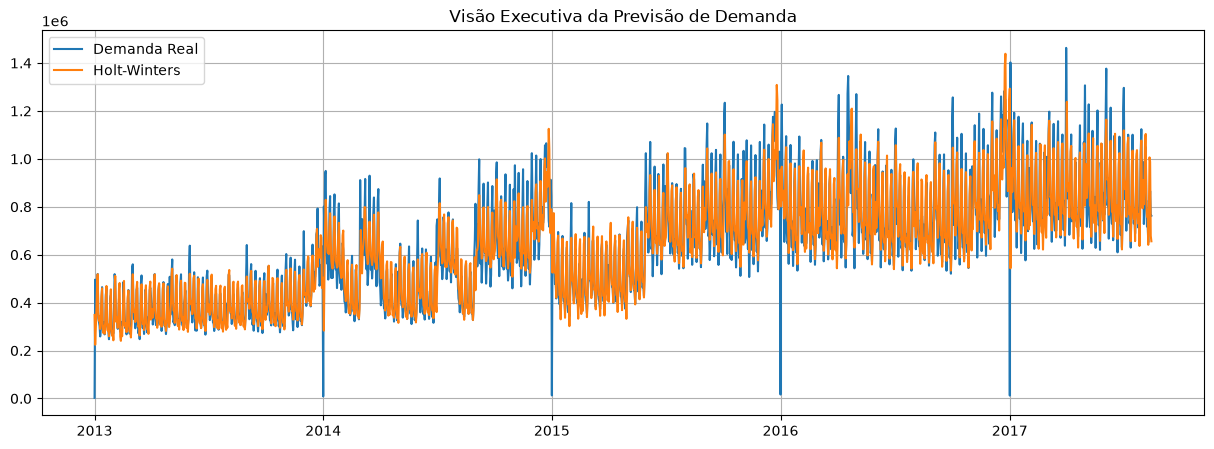

In [55]:
plt.figure(figsize=(15,5))
plt.plot(sales, label="Demanda Real")
plt.plot(forecast_hw, label="Holt-Winters")
plt.title("Visão Executiva da Previsão de Demanda")
plt.legend()
plt.grid(True)
plt.show()

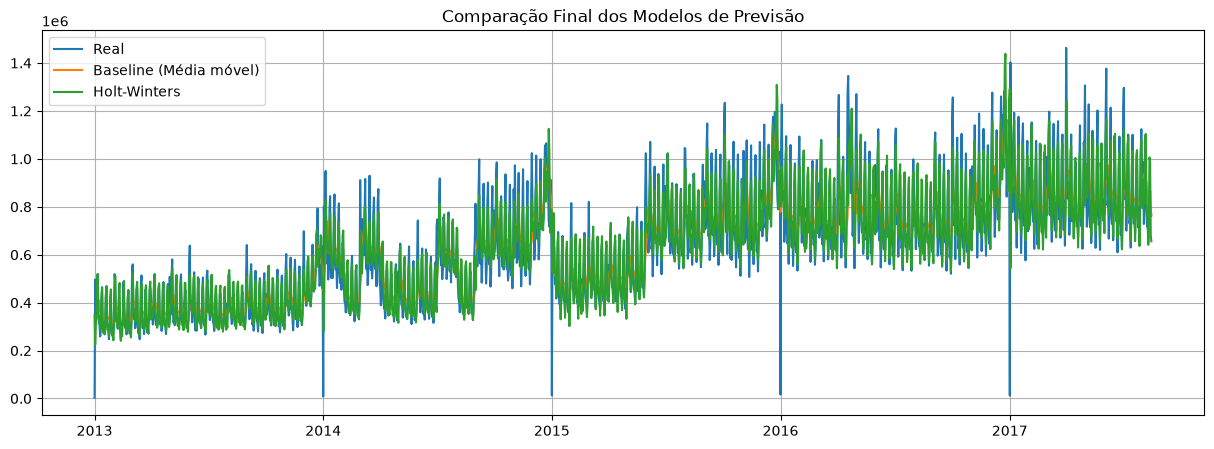

In [56]:
plt.figure(figsize=(15,5))

plt.plot(sales, label="Real")
plt.plot(forecast_baseline, label="Baseline (Média móvel)")
plt.plot(forecast_hw, label="Holt-Winters")

plt.title("Comparação Final dos Modelos de Previsão")
plt.legend()
plt.grid(True)
plt.show()

## 📊 Análise Comparativa Final

O modelo Holt-Winters apresentou melhor aderência à série temporal em comparação ao baseline baseado em média móvel.

Enquanto o baseline suaviza os dados de forma excessiva e não captura variações estruturais, o Holt-Winters consegue incorporar tendência e sazonalidade, resultando em previsões mais realistas.

---

## 📌 Conclusão Técnica

A inclusão de componentes de tendência e sazonalidade melhora significativamente a capacidade preditiva do modelo, tornando abordagens estatísticas mais robustas essenciais para problemas de previsão de demanda.

## 🧠 Conclusão da Aula 9 — Modelagem Estatística de Séries Temporais

Nesta etapa foi desenvolvido um pipeline completo de modelagem de séries temporais, incluindo abordagem baseline e modelo estatístico Holt-Winters.

Os resultados demonstraram que modelos com componentes de tendência e sazonalidade apresentam melhor desempenho em comparação a abordagens ingênuas baseadas em média móvel.

A análise de resíduos confirmou que o modelo não apresenta viés significativo, indicando boa capacidade de generalização.

Este conjunto de etapas valida a importância de modelos estatísticos estruturados para problemas de previsão de demanda.